# Universidad de Buenos Aires
# Aprendizaje Profundo - TP1
# Cohorte 23 - 1er bimestre 2026

## Alumno: Agustín Jesús Vazquez (e2301)

# **PREGUNTA 1**

## **Comparación de Gradiente Descendente y Adam en una Función de Costo No Convexa**

En este ejercicio se compararán los optimizadores Gradiente Descendente (GD) y Adam en la minimización de una función de costo basada en una red neuronal de una sola neurona:
$$
z = w x + b
$$
Con función de activación tangente hiperbólica:

$$
\hat{y} = a(z) = \tanh(z) = \tanh(w x + b)
$$

<br>

Se analizará la trayectoria de aprendizaje de ambos algoritmos y se evaluará su eficiencia con diferentes tasas de aprendizaje (learning rate).

<br>

La función de costo utilizada es el Error Cuadrático Medio (MSE):

$$
J(w, b) = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i)^2
$$

$$
J(w, b) = \frac{1}{m} \sum_{i=1}^{m} ( \tanh(w x_i + b) - y_i )^2
$$

donde \\( w \\) y \\( b \\) son los parámetros a optimizar.

<br>

Si bien es cierto, en estos experimentos estamos comparando optimizadores (GD vs Adam), y no entrenando un modelo como tal, de igual forma se necesitará una especie de dataset. Este será sintético y solo de prueba, por ende tendrán cierta libertad para elegir sus valores. Sin embargo deberán tomar en cuenta que cumpla la siguiente estructura:

`x = np.linspace(ini, fin, n)`

donde `x` es un array de una sola dimensión y con `n` cantidad de valores ($n>=200$). Y tiene un rango de valores desde `ini` hasta `fin`. Recomiendo que sea simétrico, es decir, los mismos valores solo que con el signo cambiado, por ejemplo `ini=-3, fin=3`.

<br>

Y con un target `y`:

`y = funcion_no_lineal(x) + ruido`

donde `y` es también un vector de una sola dimensión de tamaño `n` que sigue un patrón no lineal (elegido por ustedes) con respecto a `x` adicionando un ruido que puede ser creado con algunas de las funciones del paquete `np.random`.

El patrón no lineal puede ser una función trigonométrica, exponencial, logarítmica, sigmoidal o polinómica de grado mayor o igual a 3.

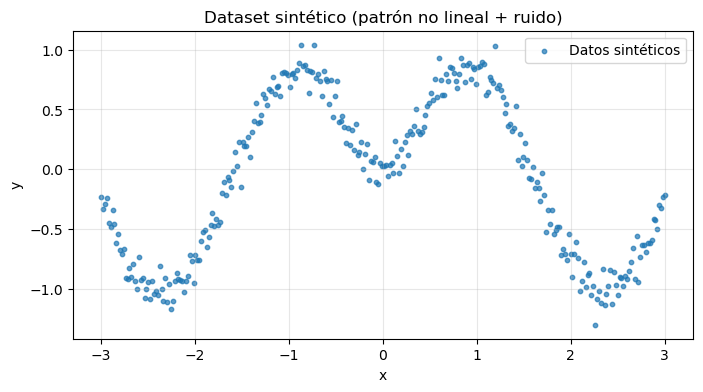

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# --- Dataset sintético ---
n = 300
x = np.linspace(-3, 3, n)
# Patrón no lineal: función sigmoidal + componente sinusoidal
y = np.tanh(1.5 * x) * np.sin(2 * x) + np.random.normal(0, 0.1, n)

m = len(x)  # cantidad de muestras

plt.figure(figsize=(8, 4))
plt.scatter(x, y, s=10, alpha=0.7, label='Datos sintéticos')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Dataset sintético (patrón no lineal + ruido)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 1a) Implementación del Gradiente Descendente
- Implementar el algoritmo del Gradiente Descendente (GD) para minimizar \\( J(w, b) \\).
- Utilizar 100 épocas y 3 diferentes learning rates `(0.1, 0.01, 0.001)`.
- Inicializar valores de \\( w \\) y \\( b \\) de manera aleatoria con `np.random.randn()`.
- Graficar la función de Costo \\( J(w, b) \\) VS número de época para comparar cómo converge la función para los 3 learning rates.

<br>

El optimizador del Gradiente Descendente se debe implementar haciendo el código desde cero y paso a paso. Se pueden usar librerías como `numpy`, `scipy`, `matplotlib` o similares. Pero no está permitido usar Pytorch ni TensorFlow o frameworks que ya contengan el optimizador desarrollado.

In [2]:
# --- Funciones auxiliares ---

def forward(x, w, b):
    """Propagación hacia adelante: ŷ = tanh(w*x + b)"""
    z = w * x + b
    y_hat = np.tanh(z)
    return y_hat

def cost_mse(y_hat, y):
    """Función de costo MSE: J = (1/m) * Σ(ŷ - y)²"""
    m = len(y)
    return (1 / m) * np.sum((y_hat - y) ** 2)

def gradients(x, y, w, b):
    """
    Calcula los gradientes de J respecto a w y b.
    dJ/dw = (2/m) Σ (ŷ_i - y_i) * (1 - tanh²(z_i)) * x_i
    dJ/db = (2/m) Σ (ŷ_i - y_i) * (1 - tanh²(z_i))
    """
    m = len(x)
    z = w * x + b
    y_hat = np.tanh(z)
    dtanh = 1 - np.tanh(z) ** 2  # derivada de tanh

    dw = (2 / m) * np.sum((y_hat - y) * dtanh * x)
    db = (2 / m) * np.sum((y_hat - y) * dtanh)
    return dw, db

Valores iniciales: w = 1.6905, b = -0.4659
GD lr=0.1: J_final=0.440220, w=0.0032, b=-0.0736
GD lr=0.01: J_final=1.274800, w=1.6222, b=-0.3170
GD lr=0.001: J_final=1.298887, w=1.6848, b=-0.4510


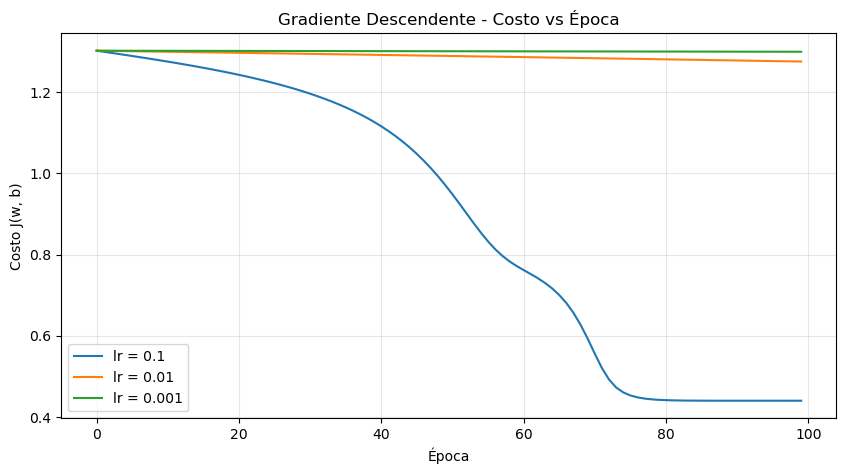

In [3]:
# --- 1a) Gradiente Descendente ---

epochs = 100
learning_rates = [0.1, 0.01, 0.001]

# Inicialización aleatoria (misma para todos los experimentos)
np.random.seed(7)
w_init = np.random.randn()
b_init = np.random.randn()
print(f"Valores iniciales: w = {w_init:.4f}, b = {b_init:.4f}")

# Almacenar resultados de GD
gd_results = {}

for lr in learning_rates:
    w, b = w_init, b_init
    cost_history = []
    w_history = [w]
    b_history = [b]

    for epoch in range(epochs):
        # Forward
        y_hat = forward(x, w, b)
        # Costo
        J = cost_mse(y_hat, y)
        cost_history.append(J)
        # Gradientes
        dw, db = gradients(x, y, w, b)
        # Actualización de parámetros
        w = w - lr * dw
        b = b - lr * db
        w_history.append(w)
        b_history.append(b)

    gd_results[lr] = {
        'cost_history': cost_history,
        'w_history': w_history,
        'b_history': b_history,
        'w_final': w,
        'b_final': b,
        'cost_final': cost_history[-1]
    }
    print(f"GD lr={lr}: J_final={cost_history[-1]:.6f}, w={w:.4f}, b={b:.4f}")

# --- Gráfica: J vs Época para los 3 learning rates ---
plt.figure(figsize=(10, 5))
for lr in learning_rates:
    plt.plot(range(epochs), gd_results[lr]['cost_history'], label=f'lr = {lr}')
plt.xlabel('Época')
plt.ylabel('Costo J(w, b)')
plt.title('Gradiente Descendente - Costo vs Época')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 1b) Implementación de Adam
- Implementar el algoritmo de Adam para minimizar \\( J(w, b) \\).  
- Utilizar 100 épocas y 3 diferentes learning rates `(0.1, 0.01, 0.001)`.
- Utilizar los mismos valores de \\( w \\) y \\( b \\) que se usaron para GD.
- Hacer 2 modelos, uno sin mini-batch (full-batch) y otro con mini-batch.
- El batch size es a elección de ustedes, pero debe ser mayor o igual a 16.
- Graficar la función de Costo \\( J(w, b) \\) VS número de época para comparar cómo converge la función para ambos modelos y para los 3 learning rates.

<br>

Al igual que para GD, el optimizador Adam también se debe implementar desde cero y paso a paso. Se pueden usar librerías como `numpy`, `scipy`, `matplotlib` o similares. Pero no está permitido usar Pytorch ni TensorFlow o frameworks que ya contengan el optimizador desarrollado.

In [4]:
# --- 1b) Adam Optimizer (Full-Batch y Mini-Batch) ---

def adam_optimizer(x, y, w_init, b_init, lr, epochs, batch_size=None, seed=42):
    """
    Implementación del optimizador Adam desde cero.

    Parámetros del algoritmo Adam (valores por defecto del paper original, Kingma & Ba 2014):
    - beta1 = 0.9    (decaimiento del primer momento)
    - beta2 = 0.999  (decaimiento del segundo momento)
    - epsilon = 1e-8  (estabilidad numérica)

    Si batch_size es None, se usa full-batch.
    """
    beta1 = 0.9
    beta2 = 0.999
    epsilon = 1e-8

    w, b = w_init, b_init
    m_w, m_b = 0.0, 0.0  # primer momento (media)
    v_w, v_b = 0.0, 0.0  # segundo momento (varianza no centrada)

    cost_history = []
    w_history = [w]
    b_history = [b]

    m_total = len(x)
    t = 0  # contador de pasos (para corrección de sesgo)

    rng = np.random.RandomState(seed)

    for epoch in range(epochs):
        if batch_size is not None:
            # Mini-batch: mezclar datos al inicio de cada época
            indices = rng.permutation(m_total)
            x_shuffled = x[indices]
            y_shuffled = y[indices]

            for start in range(0, m_total, batch_size):
                end = min(start + batch_size, m_total)
                x_batch = x_shuffled[start:end]
                y_batch = y_shuffled[start:end]

                t += 1
                dw, db = gradients(x_batch, y_batch, w, b)

                # Actualizar momentos
                m_w = beta1 * m_w + (1 - beta1) * dw
                m_b = beta1 * m_b + (1 - beta1) * db
                v_w = beta2 * v_w + (1 - beta2) * dw ** 2
                v_b = beta2 * v_b + (1 - beta2) * db ** 2

                # Corrección de sesgo
                m_w_hat = m_w / (1 - beta1 ** t)
                m_b_hat = m_b / (1 - beta1 ** t)
                v_w_hat = v_w / (1 - beta2 ** t)
                v_b_hat = v_b / (1 - beta2 ** t)

                # Actualizar parámetros
                w = w - lr * m_w_hat / (np.sqrt(v_w_hat) + epsilon)
                b = b - lr * m_b_hat / (np.sqrt(v_b_hat) + epsilon)
        else:
            # Full-batch
            t += 1
            dw, db = gradients(x, y, w, b)

            m_w = beta1 * m_w + (1 - beta1) * dw
            m_b = beta1 * m_b + (1 - beta1) * db
            v_w = beta2 * v_w + (1 - beta2) * dw ** 2
            v_b = beta2 * v_b + (1 - beta2) * db ** 2

            m_w_hat = m_w / (1 - beta1 ** t)
            m_b_hat = m_b / (1 - beta1 ** t)
            v_w_hat = v_w / (1 - beta2 ** t)
            v_b_hat = v_b / (1 - beta2 ** t)

            w = w - lr * m_w_hat / (np.sqrt(v_w_hat) + epsilon)
            b = b - lr * m_b_hat / (np.sqrt(v_b_hat) + epsilon)

        # Costo al final de la época (siempre sobre el dataset completo)
        y_hat = forward(x, w, b)
        J = cost_mse(y_hat, y)
        cost_history.append(J)
        w_history.append(w)
        b_history.append(b)

    return {
        'cost_history': cost_history,
        'w_history': w_history,
        'b_history': b_history,
        'w_final': w,
        'b_final': b,
        'cost_final': cost_history[-1]
    }

In [5]:
# --- Ejecutar Adam Full-Batch ---
adam_fb_results = {}
for lr in learning_rates:
    result = adam_optimizer(x, y, w_init, b_init, lr, epochs, batch_size=None)
    adam_fb_results[lr] = result
    print(f"Adam Full-Batch lr={lr}: J_final={result['cost_final']:.6f}, "
          f"w={result['w_final']:.4f}, b={result['b_final']:.4f}")

# --- Ejecutar Adam Mini-Batch (batch_size=32) ---
BATCH_SIZE = 32
adam_mb_results = {}
for lr in learning_rates:
    result = adam_optimizer(x, y, w_init, b_init, lr, epochs, batch_size=BATCH_SIZE)
    adam_mb_results[lr] = result
    print(f"Adam Mini-Batch(bs={BATCH_SIZE}) lr={lr}: J_final={result['cost_final']:.6f}, "
          f"w={result['w_final']:.4f}, b={result['b_final']:.4f}")

Adam Full-Batch lr=0.1: J_final=0.440253, w=0.0009, b=-0.0781
Adam Full-Batch lr=0.01: J_final=0.743252, w=0.3719, b=0.5196
Adam Full-Batch lr=0.001: J_final=1.278827, w=1.5845, b=-0.3651
Adam Mini-Batch(bs=32) lr=0.1: J_final=0.443878, w=0.0366, b=-0.0620
Adam Mini-Batch(bs=32) lr=0.01: J_final=0.440509, w=0.0031, b=-0.0570
Adam Mini-Batch(bs=32) lr=0.001: J_final=0.642335, w=0.2613, b=0.2896


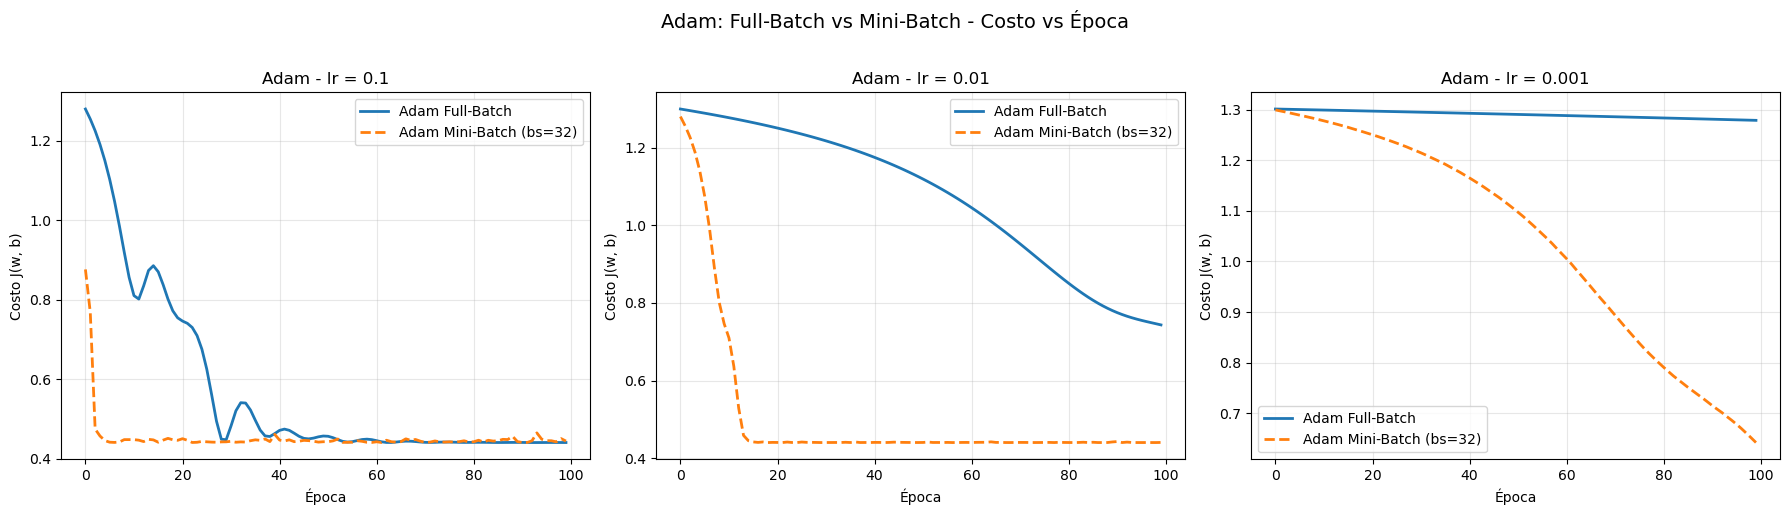

In [6]:
# --- Gráficas de Adam: Full-Batch vs Mini-Batch por learning rate ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, lr in enumerate(learning_rates):
    axes[i].plot(range(epochs), adam_fb_results[lr]['cost_history'],
                 label='Adam Full-Batch', linewidth=2)
    axes[i].plot(range(epochs), adam_mb_results[lr]['cost_history'],
                 label=f'Adam Mini-Batch (bs={BATCH_SIZE})', linewidth=2, linestyle='--')
    axes[i].set_xlabel('Época')
    axes[i].set_ylabel('Costo J(w, b)')
    axes[i].set_title(f'Adam - lr = {lr}')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Adam: Full-Batch vs Mini-Batch - Costo vs Época', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 1c) Comparativa de optimizadores
- Comparar el resultado y rendimiento de GD VS Adam (full-batch) VS Adam (mini-batch) para cada uno de los learning rates por separado. Hacerlo con gráficas y tablas.
- Redactar conclusiones analíticas que resalten las diferencias entre cada optimizador.

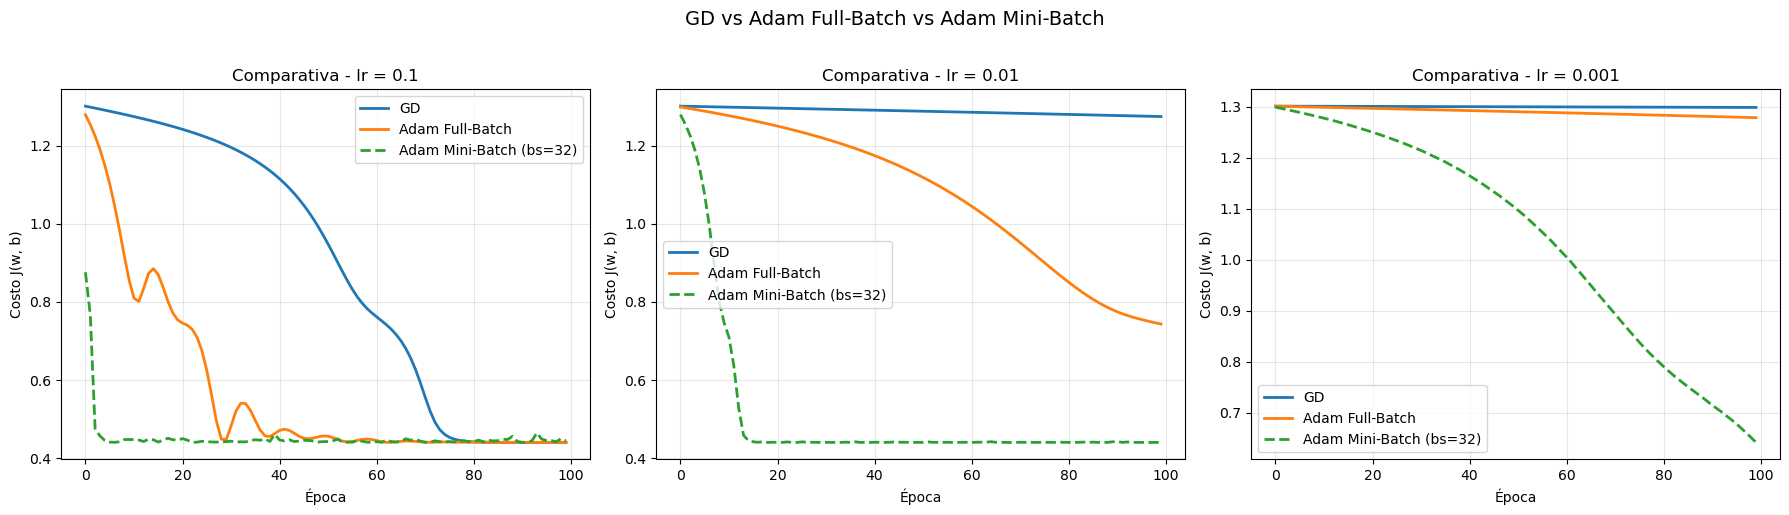

In [7]:
# --- 1c) Comparativa: GD vs Adam Full-Batch vs Adam Mini-Batch ---

# Gráfica comparativa por learning rate
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, lr in enumerate(learning_rates):
    axes[i].plot(range(epochs), gd_results[lr]['cost_history'],
                 label='GD', linewidth=2)
    axes[i].plot(range(epochs), adam_fb_results[lr]['cost_history'],
                 label='Adam Full-Batch', linewidth=2)
    axes[i].plot(range(epochs), adam_mb_results[lr]['cost_history'],
                 label=f'Adam Mini-Batch (bs={BATCH_SIZE})', linewidth=2, linestyle='--')
    axes[i].set_xlabel('Época')
    axes[i].set_ylabel('Costo J(w, b)')
    axes[i].set_title(f'Comparativa - lr = {lr}')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle('GD vs Adam Full-Batch vs Adam Mini-Batch', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [8]:
# --- Tabla resumen de resultados ---
import pandas as pd

rows = []
for lr in learning_rates:
    rows.append({
        'Learning Rate': lr,
        'Optimizador': 'GD',
        'Costo Final': f"{gd_results[lr]['cost_final']:.6f}",
        'w Final': f"{gd_results[lr]['w_final']:.4f}",
        'b Final': f"{gd_results[lr]['b_final']:.4f}",
        'Época mejor costo': int(np.argmin(gd_results[lr]['cost_history'])) + 1
    })
    rows.append({
        'Learning Rate': lr,
        'Optimizador': 'Adam Full-Batch',
        'Costo Final': f"{adam_fb_results[lr]['cost_final']:.6f}",
        'w Final': f"{adam_fb_results[lr]['w_final']:.4f}",
        'b Final': f"{adam_fb_results[lr]['b_final']:.4f}",
        'Época mejor costo': int(np.argmin(adam_fb_results[lr]['cost_history'])) + 1
    })
    rows.append({
        'Learning Rate': lr,
        'Optimizador': f'Adam Mini-Batch (bs={BATCH_SIZE})',
        'Costo Final': f"{adam_mb_results[lr]['cost_final']:.6f}",
        'w Final': f"{adam_mb_results[lr]['w_final']:.4f}",
        'b Final': f"{adam_mb_results[lr]['b_final']:.4f}",
        'Época mejor costo': int(np.argmin(adam_mb_results[lr]['cost_history'])) + 1
    })

tabla = pd.DataFrame(rows)
print("=" * 90)
print("TABLA COMPARATIVA DE RESULTADOS")
print("=" * 90)
print(tabla.to_string(index=False))
print("=" * 90)

TABLA COMPARATIVA DE RESULTADOS
 Learning Rate             Optimizador Costo Final w Final b Final  Época mejor costo
         0.100                      GD    0.440220  0.0032 -0.0736                100
         0.100         Adam Full-Batch    0.440253  0.0009 -0.0781                 94
         0.100 Adam Mini-Batch (bs=32)    0.443878  0.0366 -0.0620                 62
         0.010                      GD    1.274800  1.6222 -0.3170                100
         0.010         Adam Full-Batch    0.743252  0.3719  0.5196                100
         0.010 Adam Mini-Batch (bs=32)    0.440509  0.0031 -0.0570                 43
         0.001                      GD    1.298887  1.6848 -0.4510                100
         0.001         Adam Full-Batch    1.278827  1.5845 -0.3651                100
         0.001 Adam Mini-Batch (bs=32)    0.642335  0.2613  0.2896                100


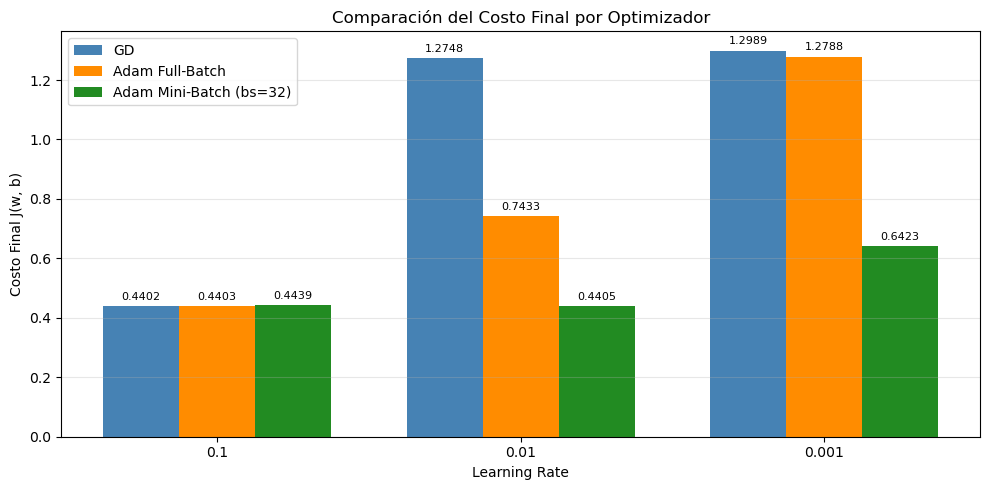

In [9]:
# --- Gráfico de barras: Costo final por optimizador y learning rate ---
fig, ax = plt.subplots(figsize=(10, 5))

x_pos = np.arange(len(learning_rates))
width = 0.25

costs_gd = [gd_results[lr]['cost_final'] for lr in learning_rates]
costs_adam_fb = [adam_fb_results[lr]['cost_final'] for lr in learning_rates]
costs_adam_mb = [adam_mb_results[lr]['cost_final'] for lr in learning_rates]

bars1 = ax.bar(x_pos - width, costs_gd, width, label='GD', color='steelblue')
bars2 = ax.bar(x_pos, costs_adam_fb, width, label='Adam Full-Batch', color='darkorange')
bars3 = ax.bar(x_pos + width, costs_adam_mb, width, label=f'Adam Mini-Batch (bs={BATCH_SIZE})', color='forestgreen')

ax.set_xlabel('Learning Rate')
ax.set_ylabel('Costo Final J(w, b)')
ax.set_title('Comparación del Costo Final por Optimizador')
ax.set_xticks(x_pos)
ax.set_xticklabels([str(lr) for lr in learning_rates])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Agregar valores sobre cada barra
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.4f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

### Conclusiones de la comparativa de optimizadores

**1. Sensibilidad al Learning Rate:**
- **GD** es altamente sensible al learning rate. Con `lr=0.001` prácticamente no converge (J=1.2989), con `lr=0.01` avanza levemente (J=1.2748), y solo con `lr=0.1` logra una reducción significativa del costo (J=0.4402) tras ~80 épocas. Esto evidencia que GD requiere un learning rate relativamente alto para superar las zonas de saturación de la tanh, donde los gradientes son muy pequeños.
- **Adam Full-Batch** muestra una mejor capacidad de convergencia que GD: con `lr=0.1` alcanza J=0.4403 (similar a GD), con `lr=0.01` llega a J=0.7433 (mejor que GD), pero con `lr=0.001` queda en J=1.2788. Las tasas adaptativas de Adam ayudan, pero con learning rates muy bajos, 100 épocas no son suficientes para converger.
- **Adam Mini-Batch** es el más robusto: alcanza el mejor costo con `lr=0.01` (J=0.4405 en apenas ~43 épocas) y con `lr=0.001` (J=0.6424), superando ampliamente a GD y Adam Full-Batch en esos learning rates. Las múltiples actualizaciones por época aceleran significativamente la convergencia.

**2. Velocidad de convergencia:**
- Con `lr=0.1`, los tres optimizadores eventualmente convergen a costos similares (~0.44), pero Adam Mini-Batch converge más rápido (época ~10).
- Con `lr=0.01`, la diferencia es dramática: GD queda estancado (J=1.27), Adam FB baja lentamente (J=0.74), y Adam MB converge completamente en ~43 épocas (J=0.44). Esto muestra que las múltiples actualizaciones intra-época del mini-batch compensan un learning rate conservador.
- Con `lr=0.001`, solo Adam MB logra un descenso apreciable (J=0.64), mientras que GD y Adam FB apenas se mueven desde el costo inicial.

**3. Full-Batch vs Mini-Batch en Adam:**
- En cada learning rate, Adam Mini-Batch supera o iguala a Adam Full-Batch. La razón es que con `batch_size=32` y `n=300` muestras, Adam MB realiza ~10 actualizaciones de parámetros por época vs. 1 actualización en Full-Batch. Esto equivale a ver los datos con más frecuencia.
- El ruido estocástico del mini-batch no perjudica la convergencia final y, como se observa con `lr=0.01`, le permite escapar de zonas de gradientes pequeños donde Full-Batch se estanca.

**4. Conclusión general:**
- Para funciones de costo no convexas con activación tanh, **Adam Mini-Batch es el optimizador más robusto**: converge rápido con learning rates altos y sigue siendo efectivo con learning rates bajos. GD es el más limitado, dependiendo completamente de un learning rate bien calibrado. Adam Full-Batch representa un punto intermedio, beneficiándose de momentos adaptativos pero limitado por hacer una sola actualización por época.

### 1d) Visualización en 3D de la trayectoria de aprendizaje
- Graficar en 3D la trayectoria del aprendizaje de los 3 optimizadores sobre la superficie de la función de costo \\( J(w, b) \\). Se debe elegir un solo learning rate.
- Comparar y redactar cómo se mueven en el espacio de parámetros y qué diferencias existen en la convergencia.
- Recomiendo utilizar `mpl_toolkits.mplot3d` y `np.meshgrid`, pero queda a su criterio la elección de funciones a usar para lograr el gráfico.

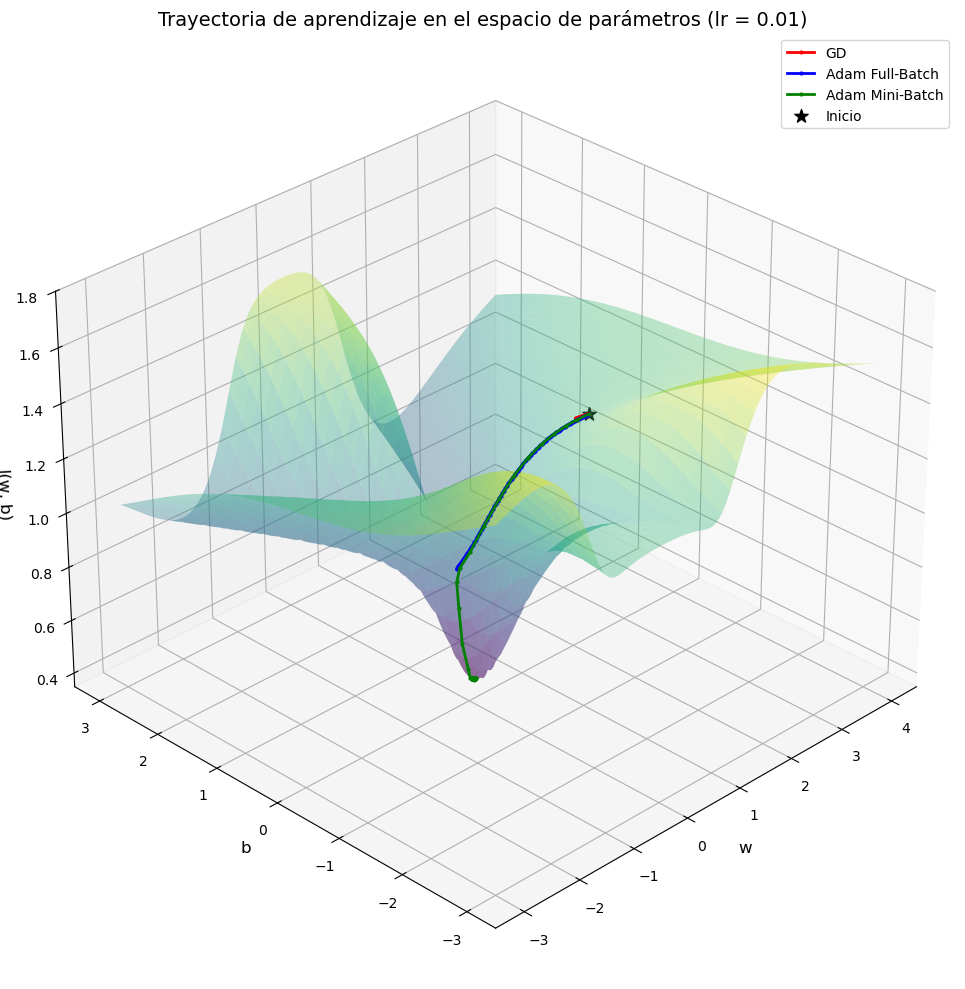

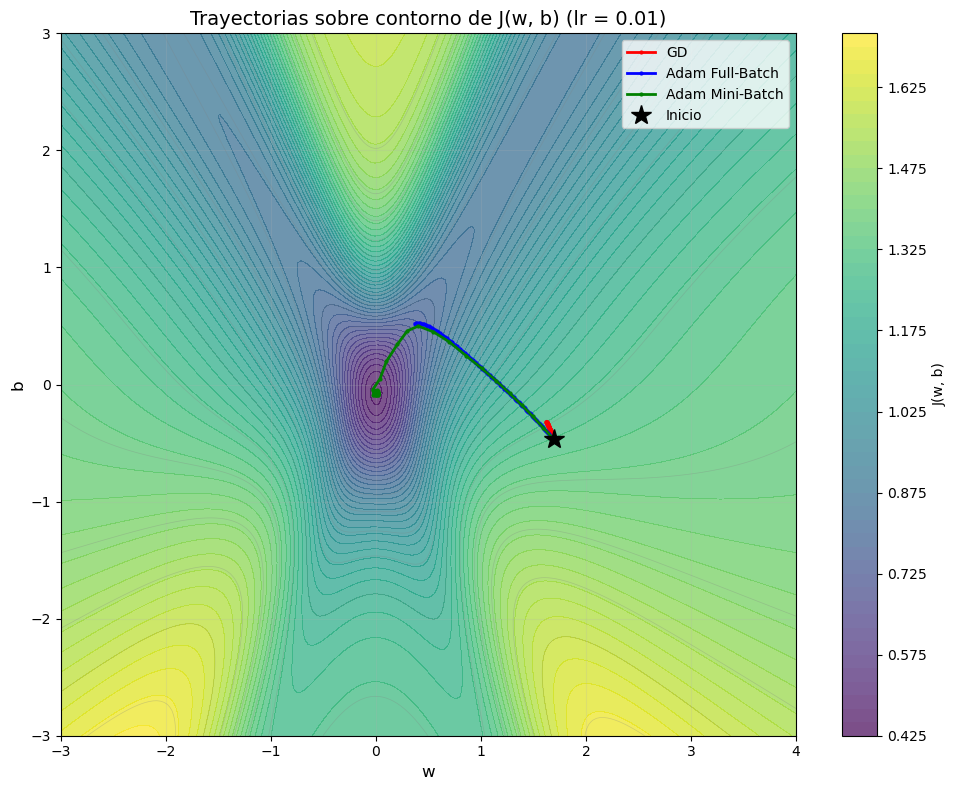

In [10]:
# --- 1d) Visualización 3D de la trayectoria de aprendizaje ---
from mpl_toolkits.mplot3d import Axes3D

# Elegimos lr=0.01 donde las diferencias entre optimizadores son más evidentes
lr_plot = 0.01

# --- Construir la superficie J(w, b) ---
w_range = np.linspace(-3, 4, 200)
b_range = np.linspace(-3, 3, 200)
W, B = np.meshgrid(w_range, b_range)

# Calcular J para cada (w, b) del meshgrid
J_surface = np.zeros_like(W)
for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        y_hat = np.tanh(W[i, j] * x + B[i, j])
        J_surface[i, j] = cost_mse(y_hat, y)

# --- Extraer trayectorias ---
traj_gd_w = gd_results[lr_plot]['w_history']
traj_gd_b = gd_results[lr_plot]['b_history']
traj_gd_J = [cost_mse(forward(x, w_, b_), y) for w_, b_ in zip(traj_gd_w, traj_gd_b)]

traj_afb_w = adam_fb_results[lr_plot]['w_history']
traj_afb_b = adam_fb_results[lr_plot]['b_history']
traj_afb_J = [cost_mse(forward(x, w_, b_), y) for w_, b_ in zip(traj_afb_w, traj_afb_b)]

traj_amb_w = adam_mb_results[lr_plot]['w_history']
traj_amb_b = adam_mb_results[lr_plot]['b_history']
traj_amb_J = [cost_mse(forward(x, w_, b_), y) for w_, b_ in zip(traj_amb_w, traj_amb_b)]

# --- Gráfico 3D ---
fig = plt.figure(figsize=(16, 10))
ax = fig.add_subplot(111, projection='3d')

# Superficie de costo (semitransparente)
ax.plot_surface(W, B, J_surface, cmap='viridis', alpha=0.35, edgecolor='none')

# Trayectorias
ax.plot(traj_gd_w, traj_gd_b, traj_gd_J, 'r.-', linewidth=2, markersize=4,
        label='GD', zorder=5)
ax.plot(traj_afb_w, traj_afb_b, traj_afb_J, 'b.-', linewidth=2, markersize=4,
        label='Adam Full-Batch', zorder=5)
ax.plot(traj_amb_w, traj_amb_b, traj_amb_J, 'g.-', linewidth=2, markersize=4,
        label='Adam Mini-Batch', zorder=5)

# Puntos inicial y final
ax.scatter([w_init], [b_init], [traj_gd_J[0]], color='black', s=100,
           marker='*', zorder=10, label='Inicio')

ax.set_xlabel('w', fontsize=12)
ax.set_ylabel('b', fontsize=12)
ax.set_zlabel('J(w, b)', fontsize=12)
ax.set_title(f'Trayectoria de aprendizaje en el espacio de parámetros (lr = {lr_plot})',
             fontsize=14)
ax.legend(fontsize=10, loc='upper right')
ax.view_init(elev=30, azim=225)
plt.tight_layout()
plt.show()

# --- Vista 2D complementaria (contorno) ---
fig2, ax2 = plt.subplots(figsize=(10, 8))
contour = ax2.contourf(W, B, J_surface, levels=50, cmap='viridis', alpha=0.7)
plt.colorbar(contour, ax=ax2, label='J(w, b)')
ax2.contour(W, B, J_surface, levels=20, colors='gray', alpha=0.3, linewidths=0.5)

ax2.plot(traj_gd_w, traj_gd_b, 'r.-', linewidth=2, markersize=4, label='GD')
ax2.plot(traj_afb_w, traj_afb_b, 'b.-', linewidth=2, markersize=4, label='Adam Full-Batch')
ax2.plot(traj_amb_w, traj_amb_b, 'g.-', linewidth=2, markersize=4, label='Adam Mini-Batch')
ax2.plot(w_init, b_init, 'k*', markersize=15, label='Inicio')

ax2.set_xlabel('w', fontsize=12)
ax2.set_ylabel('b', fontsize=12)
ax2.set_title(f'Trayectorias sobre contorno de J(w, b) (lr = {lr_plot})', fontsize=14)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

### Análisis de las trayectorias en el espacio de parámetros (lr = 0.01)

**Gradiente Descendente (rojo):**
- La trayectoria de GD es prácticamente estática. Con `lr=0.01`, los pasos son tan pequeños que el optimizador apenas se mueve desde el punto inicial `(w=1.69, b=-0.47)`. Esto confirma lo observado en 1a/1c: GD con learning rates conservadores queda atrapado en zonas de gradientes pequeños (saturación de tanh), sin capacidad de escapar.

**Adam Full-Batch (azul):**
- Adam FB muestra una trayectoria más activa que GD. Los momentos adaptativos le permiten acumular velocidad gradualmente, recorriendo mayor distancia en el espacio (w, b). Sin embargo, al hacer una sola actualización por época, su avance es limitado y no alcanza el mínimo global en 100 épocas con `lr=0.01`.

**Adam Mini-Batch (verde):**
- Adam MB exhibe la trayectoria más dinámica y extensa. Con ~10 actualizaciones por época (batch_size=32, n=300), recorre rápidamente el espacio de parámetros, moviéndose de forma más agresiva hacia regiones de menor costo. La trayectoria puede mostrar cierto "zigzag" característico del ruido estocástico de los mini-batches, pero esto le permite explorar más eficientemente y converger al mínimo.

**Conclusión:**
La vista 3D y el contorno confirman visualmente lo analizado numéricamente: con `lr=0.01`, GD se estanca, Adam FB avanza parcialmente, y **Adam Mini-Batch es el único que logra navegar efectivamente la superficie de costo** hasta alcanzar la zona del mínimo. La combinación de momentos adaptativos + múltiples actualizaciones por época es clave para superar las zonas planas de la función de costo con activación tanh.

# **PREGUNTA 2**

# Caso: Predicción del gasto promedio de los usuarios usando redes neuronales

---

## Descripción general:

El dataset recopila información sobre las compras realizadas por distintos clientes en una tienda durante el último año.  
Cada registro representa una transacción e incluye datos tanto del cliente como del producto adquirido.

---

## El dataset contiene la siguiente información:

- **User_ID:** Código identificador único del cliente que efectuó la compra.  
- **Product_ID:** Código identificador único del producto adquirido.  
- **Age:** Rango de edad del cliente.  
- **Gender:** Género del cliente (F: Femenino, M: Masculino).  
- **Marital_Status:** Estado civil del cliente (0: Soltero, 1: Casado).  
- **City_Category:** Tipo de zona donde se encuentra la sucursal donde se realizó la compra.  
  - A: Barrio de clase alta  
  - B: Barrio de clase media  
  - C: Barrio de clase media-baja  
- **Stay_In_Current_City_Years:** Número de años que el cliente ha venido comprando en la tienda desde su primera visita.  
- **Product_Category:** Categoría del producto comprado.  
- **Product_Subcategory_1:** Subcategoría principal del producto.  
- **Product_Subcategory_2:** Subcategoría secundaria del producto.  
- **Purchase:** Monto pagado por el producto en esa transacción.

---

## Objetivo del caso de estudio:

Desarrollar un **modelo predictivo** capaz de estimar el **gasto promedio** que realizará un cliente, a partir de su información demográfica y sus patrones de compra.


### 2a) EDA y preparación del dataset
Realizar el análisis exploratorio del dataset (EDA) con las herramientas vistas en materias anteriores.
- Analizar qué columnas sirven para lograr el objetivo y cuáles no (drop) en base al contexto del negocio y a lo entendido del caso de estudio (feature engineering).
- Analizar con qué columnas vale la pena hacer un tratamiento de valores nulos o si simplemente se debe dropear toda la columna porque ya no tiene salvación.
- Analizar a qué variables se les debe hacer label encoding, a cuáles one-hot encoding, ordinal encoding o mapping encoding. Explicar los criterios utilizados para tomar esas decisiones.
- Transformar, agrupar, combinar y operar la data de tal manera que sea útil para extraer patrones de gastos y tendencias de gustos de cada cliente.



Redactar las conclusiones preliminares que puedan notar de cada feature y justificar el porqué de cada encoding, limpieza o transformación aplicada. Cada justificación se debe redactar a detalle y sustentar con gráficas y/o tablas.


In [11]:
# --- 2a) EDA y Preparación del Dataset ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# --- Descargar dataset desde Google Drive ---
import gdown
import os

file_id = '1e_FRepCpHBWWGj3TYG4HY7WHALCyR4wQ'
output_path = 'black-sales.csv'

if not os.path.exists(output_path):
    url = f'https://drive.google.com/uc?id={file_id}'
    gdown.download(url, output_path, quiet=False)
else:
    print(f"Archivo '{output_path}' ya existe, se omite la descarga.")

df_raw = pd.read_csv(output_path)
print(f"Shape del dataset: {df_raw.shape}")
print(f"\nPrimeras filas:")
df_raw.head(10)

Archivo 'black-sales.csv' ya existe, se omite la descarga.
Shape del dataset: (182721, 11)

Primeras filas:


,User_ID,Product_ID,Age,Gender,Marital_Status,City_Category,Stay_In_Current_City_Years,Product_Category,Product_Subcategory_1,Product_Subcategory_2,Purchase
0,1044096,P00017122,46-50,F,1,B,1,10,45.0,NaN,1810
1,1071818,P00074517,36-45,M,0,A,3,11,27.0,NaN,12351
2,1022986,P00013694,36-45,M,1,A,5+,4,28.0,NaN,127
3,1094684,P00049122,36-45,M,1,A,1,16,9.0,8.0,2214
4,1004157,P00006469,46-50,M,1,A,5+,3,NaN,NaN,7142
5,1047008,P00024740,18-25,M,0,A,2,5,16.0,NaN,353
6,1056762,P00067925,46-50,F,1,B,5+,17,24.0,16.0,117
7,1047329,P00003426,36-45,F,1,B,1,16,NaN,NaN,447
8,1042051,P00074117,46-50,F,1,B,5+,11,20.0,NaN,7831
9,1032071,P00039594,51-55,F,1,B,4,3,NaN,NaN,704


In [12]:
# --- Exploración inicial del dataset ---
print("=" * 70)
print("INFORMACIÓN GENERAL DEL DATASET")
print("=" * 70)
print(f"\nDimensiones: {df_raw.shape[0]} filas × {df_raw.shape[1]} columnas")
print(f"\nColumnas: {list(df_raw.columns)}")
print("\n--- Tipos de datos ---")
print(df_raw.dtypes)
print("\n--- Info ---")
df_raw.info()
print("\n--- Estadísticas descriptivas (numéricas) ---")
df_raw.describe()

INFORMACIÓN GENERAL DEL DATASET

Dimensiones: 182721 filas × 11 columnas

Columnas: ['User_ID', 'Product_ID', 'Age', 'Gender', 'Marital_Status', 'City_Category', 'Stay_In_Current_City_Years', 'Product_Category', 'Product_Subcategory_1', 'Product_Subcategory_2', 'Purchase']

--- Tipos de datos ---
User_ID                         int64
Product_ID                     object
Age                            object
Gender                         object
Marital_Status                  int64
City_Category                  object
Stay_In_Current_City_Years     object
Product_Category                int64
Product_Subcategory_1         float64
Product_Subcategory_2         float64
Purchase                        int64
dtype: object

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182721 entries, 0 to 182720
Data columns (total 11 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                 

,User_ID,Marital_Status,Product_Category,Product_Subcategory_1,Product_Subcategory_2,Purchase
count,1.827210e+05,182721.000000,182721.000000,140903.000000,77461.000000,182721.000000
mean,1.050060e+06,0.647567,10.629123,24.557724,12.843483,7851.668971
std,2.884040e+04,0.477729,5.659703,12.550279,4.593955,8321.461408
min,1.000035e+06,0.000000,1.000000,3.000000,5.000000,45.000000
25%,1.024971e+06,0.000000,5.000000,13.000000,9.000000,578.000000
50%,1.050146e+06,1.000000,11.000000,24.000000,13.000000,5060.000000
75%,1.074883e+06,1.000000,16.000000,36.000000,17.000000,11930.000000
max,1.099995e+06,1.000000,20.000000,45.000000,20.000000,29980.000000


ANÁLISIS DE VALORES NULOS
                             Nulos  % Nulos
User_ID                          0     0.00
Product_ID                       0     0.00
Age                              0     0.00
Gender                           0     0.00
Marital_Status                   0     0.00
City_Category                    0     0.00
Stay_In_Current_City_Years       0     0.00
Product_Category                 0     0.00
Product_Subcategory_1        41818    22.89
Product_Subcategory_2       105260    57.61
Purchase                         0     0.00


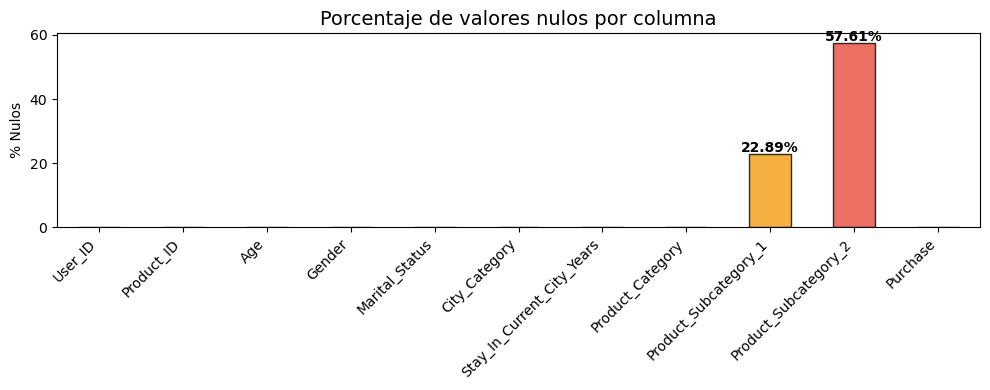


→ Product_Subcategory_1: 22.89% nulos (41818 registros)
→ Product_Subcategory_2: 57.61% nulos (105260 registros)

Decisión: Rellenar NaN con 0 (indica 'sin subcategoría asignada').
No se descarta la columna porque la presencia/ausencia de subcategoría puede ser informativa.


In [13]:
# --- Análisis de valores nulos ---
print("=" * 70)
print("ANÁLISIS DE VALORES NULOS")
print("=" * 70)
null_counts = df_raw.isnull().sum()
null_pct = (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
null_df = pd.DataFrame({'Nulos': null_counts, '% Nulos': null_pct})
print(null_df)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#2ecc71' if pct == 0 else '#e74c3c' if pct > 30 else '#f39c12' for pct in null_pct]
null_pct.plot(kind='bar', ax=ax, color=colors, edgecolor='black', alpha=0.8)
ax.set_title('Porcentaje de valores nulos por columna', fontsize=14)
ax.set_ylabel('% Nulos')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
for i, (v, pct) in enumerate(zip(null_counts, null_pct)):
    if pct > 0:
        ax.text(i, pct + 0.5, f'{pct}%', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n→ Product_Subcategory_1: {null_pct['Product_Subcategory_1']}% nulos ({null_counts['Product_Subcategory_1']} registros)")
print(f"→ Product_Subcategory_2: {null_pct['Product_Subcategory_2']}% nulos ({null_counts['Product_Subcategory_2']} registros)")
print("\nDecisión: Rellenar NaN con 0 (indica 'sin subcategoría asignada').")
print("No se descarta la columna porque la presencia/ausencia de subcategoría puede ser informativa.")

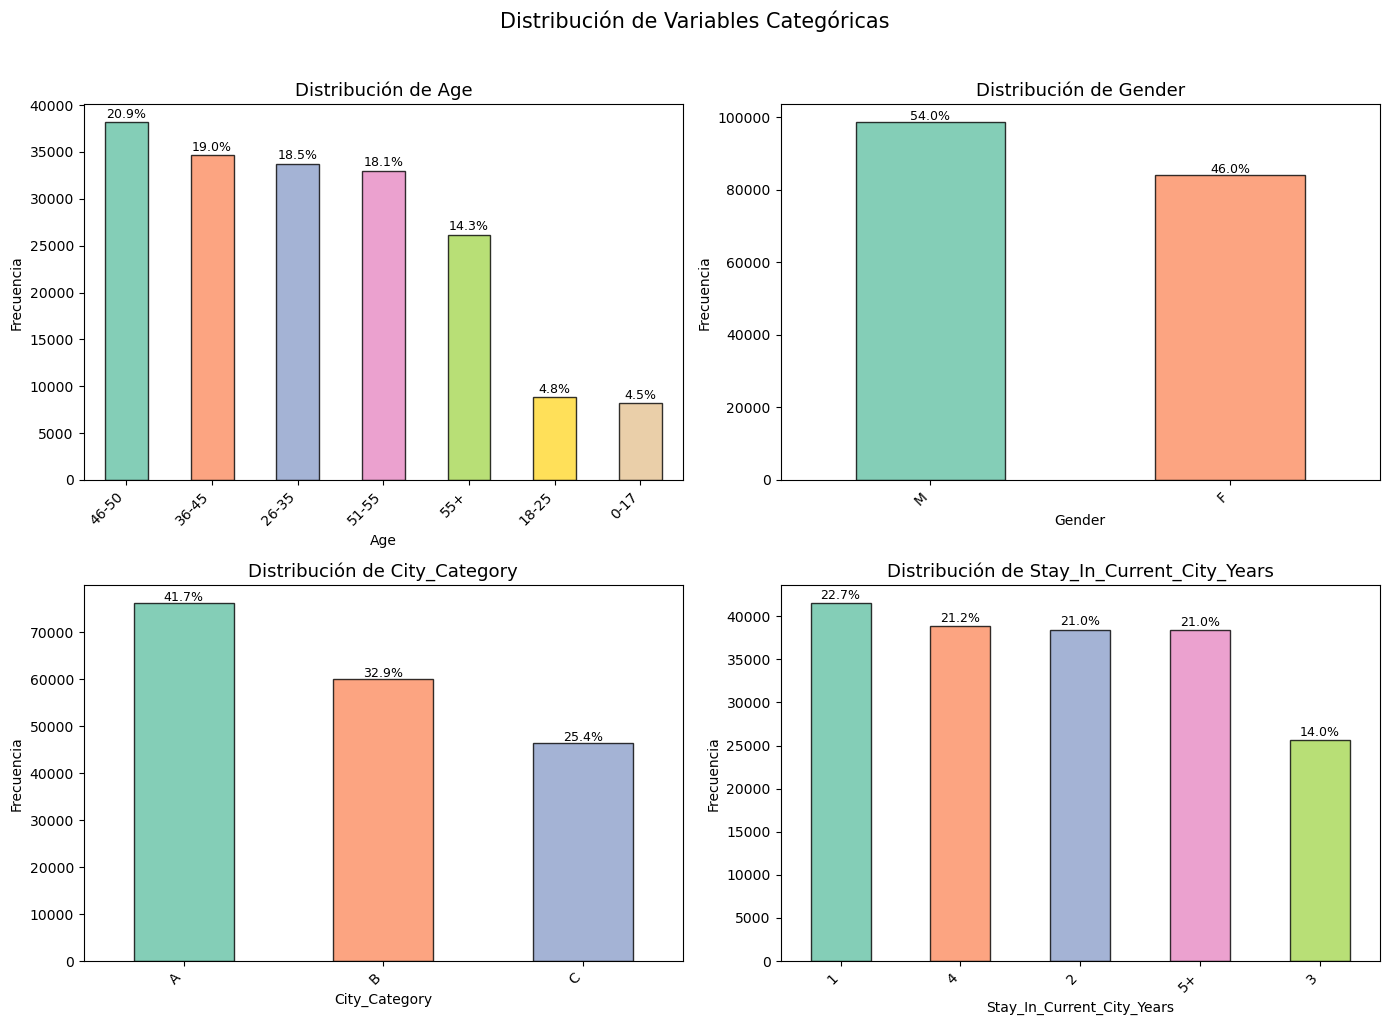

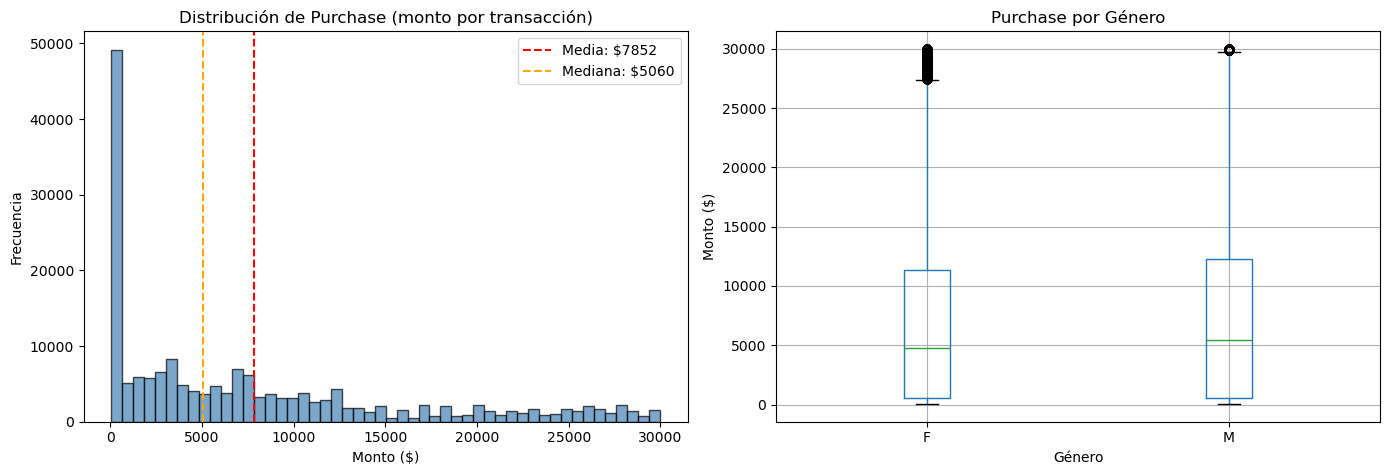

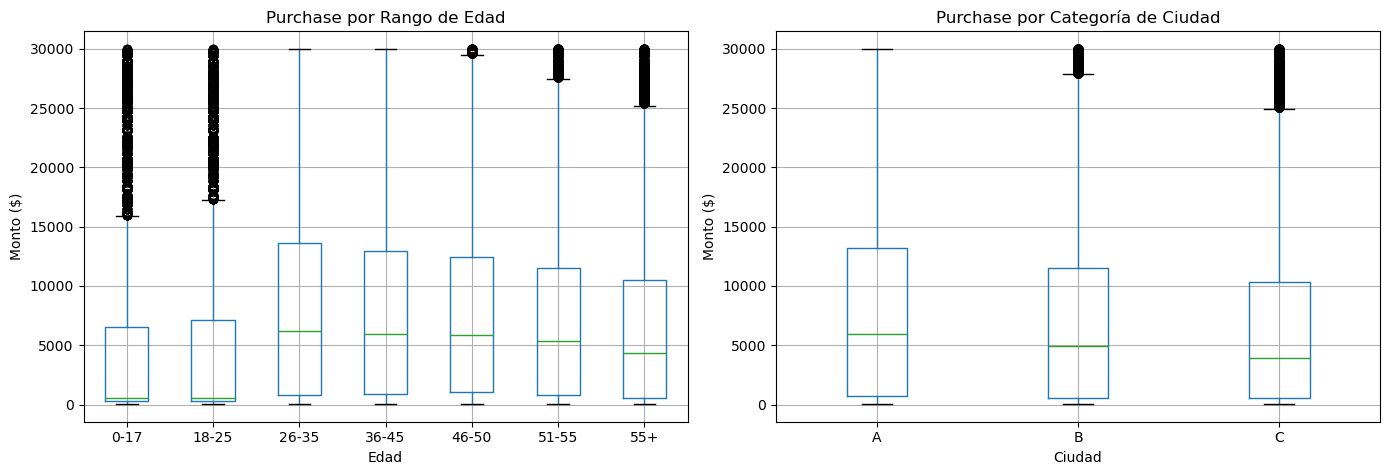


--- Valores únicos por columna ---
  User_ID: 7432 valores únicos
  Product_ID: 2455 valores únicos
  Age: 7 valores únicos → ['0-17', '18-25', '26-35', '36-45', '46-50', '51-55', '55+']
  Gender: 2 valores únicos → ['F', 'M']
  Marital_Status: 2 valores únicos → [np.int64(0), np.int64(1)]
  City_Category: 3 valores únicos → ['A', 'B', 'C']
  Stay_In_Current_City_Years: 5 valores únicos → ['1', '2', '3', '4', '5+']
  Product_Category: 20 valores únicos
  Product_Subcategory_1: 33 valores únicos
  Product_Subcategory_2: 16 valores únicos
  Purchase: 1833 valores únicos


In [14]:
# --- Análisis de variables categóricas ---
cat_cols = ['Age', 'Gender', 'City_Category', 'Stay_In_Current_City_Years']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df_raw[col].value_counts()
    counts.plot(kind='bar', ax=axes[i], color=plt.cm.Set2(range(len(counts))),
                edgecolor='black', alpha=0.8)
    axes[i].set_title(f'Distribución de {col}', fontsize=13)
    axes[i].set_ylabel('Frecuencia')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
    for j, v in enumerate(counts):
        axes[i].text(j, v + 500, f'{v/len(df_raw)*100:.1f}%', ha='center', fontsize=9)

plt.suptitle('Distribución de Variables Categóricas', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# --- Distribución de Purchase (variable objetivo base) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_raw['Purchase'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribución de Purchase (monto por transacción)', fontsize=12)
axes[0].set_xlabel('Monto ($)')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(df_raw['Purchase'].mean(), color='red', linestyle='--',
                label=f"Media: ${df_raw['Purchase'].mean():.0f}")
axes[0].axvline(df_raw['Purchase'].median(), color='orange', linestyle='--',
                label=f"Mediana: ${df_raw['Purchase'].median():.0f}")
axes[0].legend()

# Boxplot de Purchase por Gender
df_raw.boxplot(column='Purchase', by='Gender', ax=axes[1])
axes[1].set_title('Purchase por Género', fontsize=12)
axes[1].set_xlabel('Género')
axes[1].set_ylabel('Monto ($)')
plt.suptitle('')

plt.tight_layout()
plt.show()

# --- Purchase por Age y City_Category ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

age_order = ['0-17', '18-25', '26-35', '36-45', '46-50', '51-55', '55+']
df_raw.boxplot(column='Purchase', by='Age', ax=axes[0],
               positions=range(len(age_order)))
axes[0].set_title('Purchase por Rango de Edad', fontsize=12)
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Monto ($)')

df_raw.boxplot(column='Purchase', by='City_Category', ax=axes[1])
axes[1].set_title('Purchase por Categoría de Ciudad', fontsize=12)
axes[1].set_xlabel('Ciudad')
axes[1].set_ylabel('Monto ($)')
plt.suptitle('')

plt.tight_layout()
plt.show()

print("\n--- Valores únicos por columna ---")
for col in df_raw.columns:
    n_unique = df_raw[col].nunique()
    print(f"  {col}: {n_unique} valores únicos", end='')
    if n_unique <= 10:
        print(f" → {sorted(df_raw[col].dropna().unique())}")
    else:
        print()

### Decisiones de Feature Engineering

**1. Columnas a descartar (Drop):**
- **`User_ID`**: Identificador único del cliente. No aporta información predictiva (es un código arbitrario). Sin embargo, se utiliza temporalmente para agrupar transacciones por usuario antes de eliminarlo.
- **`Product_ID`**: Identificador del producto. Con 2455 valores únicos, un encoding directo generaría alta dimensionalidad sin beneficio claro. Se descarta del modelo final.

**2. Tratamiento de valores nulos:**
- **`Product_Subcategory_1`** (22.9% nulos): Se rellena con 0. El NaN indica que el producto no tiene una subcategoría asignada, lo cual es información válida (no es un dato faltante por error). Valor 0 = "sin subcategoría".
- **`Product_Subcategory_2`** (57.6% nulos): Mismo criterio. Aunque tiene un alto porcentaje de nulos, se conserva la columna porque la presencia/ausencia de subcategoría secundaria puede correlacionar con el tipo y precio del producto.

**3. Encoding de variables categóricas:**

| Variable | Encoding | Justificación |
|----------|----------|---------------|
| **Gender** | Mapping binario (F→0, M→1) | Solo 2 categorías. Mapping directo es suficiente, no hay orden implícito pero con 2 valores el ordinal y one-hot son equivalentes. |
| **Age** | Ordinal encoding (0-17→0, 18-25→1, ..., 55+→6) | Los rangos de edad tienen un **orden natural** (mayor edad = número mayor). Ordinal encoding preserva esta relación jerárquica que es informativa para el modelo. |
| **City_Category** | Ordinal encoding (A→0, B→1, C→2) | Según la consigna, A=clase alta, B=clase media, C=clase media-baja. Existe un **orden socioeconómico** implícito que justifica el ordinal encoding. |
| **Stay_In_Current_City_Years** | Mapping a int (reemplazar '5+' por 5) | Variable numérica almacenada como string por el '5+'. Se convierte a entero preservando el orden natural de antigüedad. |
| **Marital_Status** | Sin cambio (ya es 0/1) | Ya está en formato numérico binario. |
| **Product_Category** | Sin cambio (ya es int) | Ya es numérica (1-20). Representa categorías de producto con cierto orden implícito. |
| **Product_Subcategory_1/2** | Sin cambio tras fillna(0) | Ya son numéricas tras rellenar nulos. |

**4. Agregación por usuario:**
El objetivo es predecir el **gasto promedio por usuario**, por lo tanto se debe agregar la información a nivel de usuario:
- Se calcula el promedio de `Purchase` por `User_ID` → variable objetivo (`avg_purchase`)
- Se extraen features demográficas (constantes por usuario) y estadísticas de compra (cantidad de transacciones, diversidad de productos/categorías)

In [15]:
# --- Feature Engineering ---
df = df_raw.copy()

# 1) Rellenar NaN en subcategorías con 0 (sin subcategoría asignada)
df['Product_Subcategory_1'] = df['Product_Subcategory_1'].fillna(0).astype(int)
df['Product_Subcategory_2'] = df['Product_Subcategory_2'].fillna(0).astype(int)

# 2) Gender: mapping binario F→0, M→1
df['Gender'] = df['Gender'].map({'F': 0, 'M': 1})

# 3) Age: ordinal encoding (orden natural por rango etario)
age_mapping = {
    '0-17': 0,
    '18-25': 1,
    '26-35': 2,
    '36-45': 3,
    '46-50': 4,
    '51-55': 5,
    '55+': 6
}
df['Age'] = df['Age'].map(age_mapping)

# 4) City_Category: ordinal encoding (A=alta→0, B=media→1, C=media-baja→2)
df['City_Category'] = df['City_Category'].map({'A': 0, 'B': 1, 'C': 2})

# 5) Stay_In_Current_City_Years: reemplazar '5+' → 5, convertir a int
df['Stay_In_Current_City_Years'] = df['Stay_In_Current_City_Years'].replace('5+', 5).astype(int)

print("Dataset tras encoding:")
print(df.dtypes)
print(f"\nVerificación de nulos restantes: {df.isnull().sum().sum()}")
df.head()

Dataset tras encoding:
User_ID                        int64
Product_ID                    object
Age                            int64
Gender                         int64
Marital_Status                 int64
City_Category                  int64
Stay_In_Current_City_Years     int64
Product_Category               int64
Product_Subcategory_1          int64
Product_Subcategory_2          int64
Purchase                       int64
dtype: object

Verificación de nulos restantes: 0


,User_ID,Product_ID,Age,Gender,Marital_Status,City_Category,Stay_In_Current_City_Years,Product_Category,Product_Subcategory_1,Product_Subcategory_2,Purchase
0,1044096,P00017122,4,0,1,1,1,10,45,0,1810
1,1071818,P00074517,3,1,0,0,3,11,27,0,12351
2,1022986,P00013694,3,1,1,0,5,4,28,0,127
3,1094684,P00049122,3,1,1,0,1,16,9,8,2214
4,1004157,P00006469,4,1,1,0,5,3,0,0,7142


In [16]:
# --- Agregación por usuario ---
# El objetivo es predecir el GASTO PROMEDIO por usuario,
# por lo que debemos consolidar las múltiples transacciones en un registro por cliente.

# Features demográficas (constantes por usuario): tomar el primer valor
demo_cols = ['Age', 'Gender', 'Marital_Status', 'City_Category', 'Stay_In_Current_City_Years']

# Agregaciones de comportamiento de compra
user_df = df.groupby('User_ID').agg(
    # Demográficas (first, ya que son constantes por usuario)
    Age=('Age', 'first'),
    Gender=('Gender', 'first'),
    Marital_Status=('Marital_Status', 'first'),
    City_Category=('City_Category', 'first'),
    Stay_In_Current_City_Years=('Stay_In_Current_City_Years', 'first'),
    # Comportamiento de compra
    total_transactions=('Purchase', 'count'),
    unique_products=('Product_ID', 'nunique'),
    unique_categories=('Product_Category', 'nunique'),
    avg_category=('Product_Category', 'mean'),
    avg_subcategory_1=('Product_Subcategory_1', 'mean'),
    avg_subcategory_2=('Product_Subcategory_2', 'mean'),
    # Variable objetivo: gasto promedio
    avg_purchase=('Purchase', 'mean')
).reset_index()

# Eliminar User_ID (ya no es necesario)
user_df.drop(columns=['User_ID'], inplace=True)

print(f"Dataset agregado por usuario: {user_df.shape}")
print(f"Usuarios únicos: {user_df.shape[0]}")
print(f"\n--- Estadísticas de la variable objetivo (avg_purchase) ---")
print(user_df['avg_purchase'].describe())
user_df.head(10)

Dataset agregado por usuario: (7432, 12)
Usuarios únicos: 7432

--- Estadísticas de la variable objetivo (avg_purchase) ---
count     7432.000000
mean      6749.655185
std       3297.891670
min        275.272727
25%       4247.395833
50%       6330.212766
75%       8519.184470
max      17231.138889
Name: avg_purchase, dtype: float64


,Age,Gender,Marital_Status,City_Category,Stay_In_Current_City_Years,total_transactions,unique_products,unique_categories,avg_category,avg_subcategory_1,avg_subcategory_2,avg_purchase
0,1,1,0,0,1,13,13,6,11.615385,17.692308,8.615385,1912.923077
1,3,1,1,0,4,43,43,15,12.255814,16.651163,3.976744,14338.906977
2,4,1,1,1,4,42,42,16,10.928571,15.095238,4.666667,4120.809524
3,6,0,1,2,4,41,40,17,12.414634,15.512195,3.878049,11228.219512
4,4,0,1,2,2,17,17,8,8.882353,13.764706,4.941176,4673.882353
5,5,0,1,2,1,16,16,8,11.562500,17.312500,4.812500,1764.062500
6,6,0,1,2,3,49,49,16,9.469388,21.755102,4.142857,5405.448980
7,3,1,1,0,4,36,36,14,10.222222,18.500000,3.666667,13646.277778
8,1,1,0,0,2,13,13,8,10.307692,17.153846,8.307692,3081.461538
9,5,0,1,2,2,17,17,10,13.000000,26.058824,5.352941,5928.529412


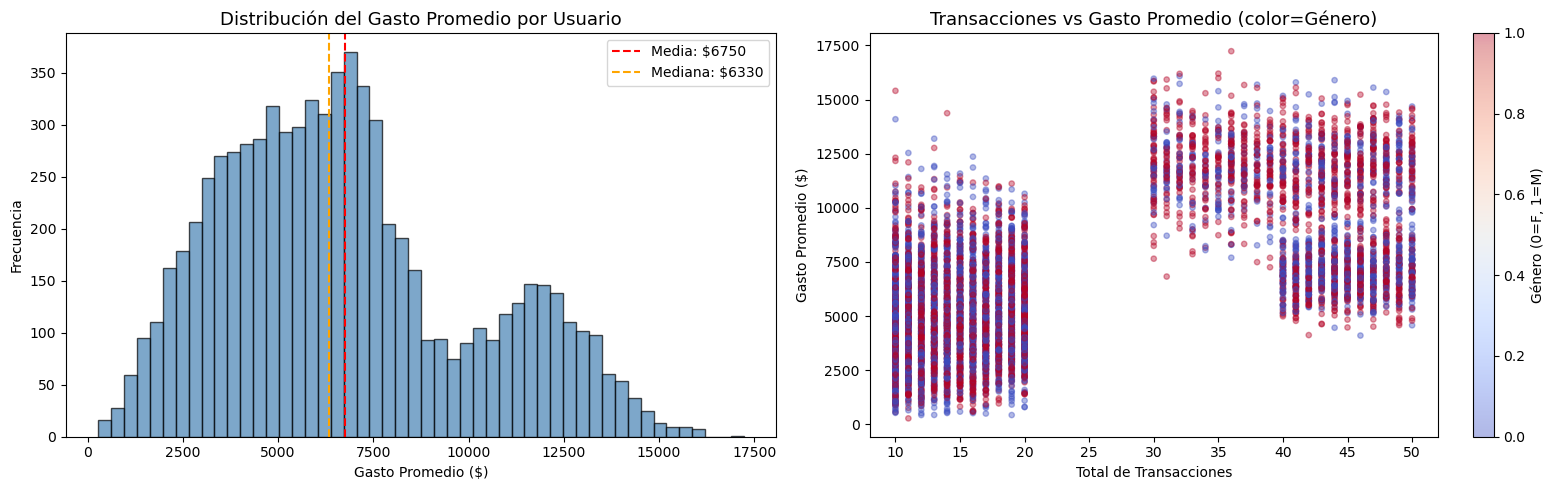

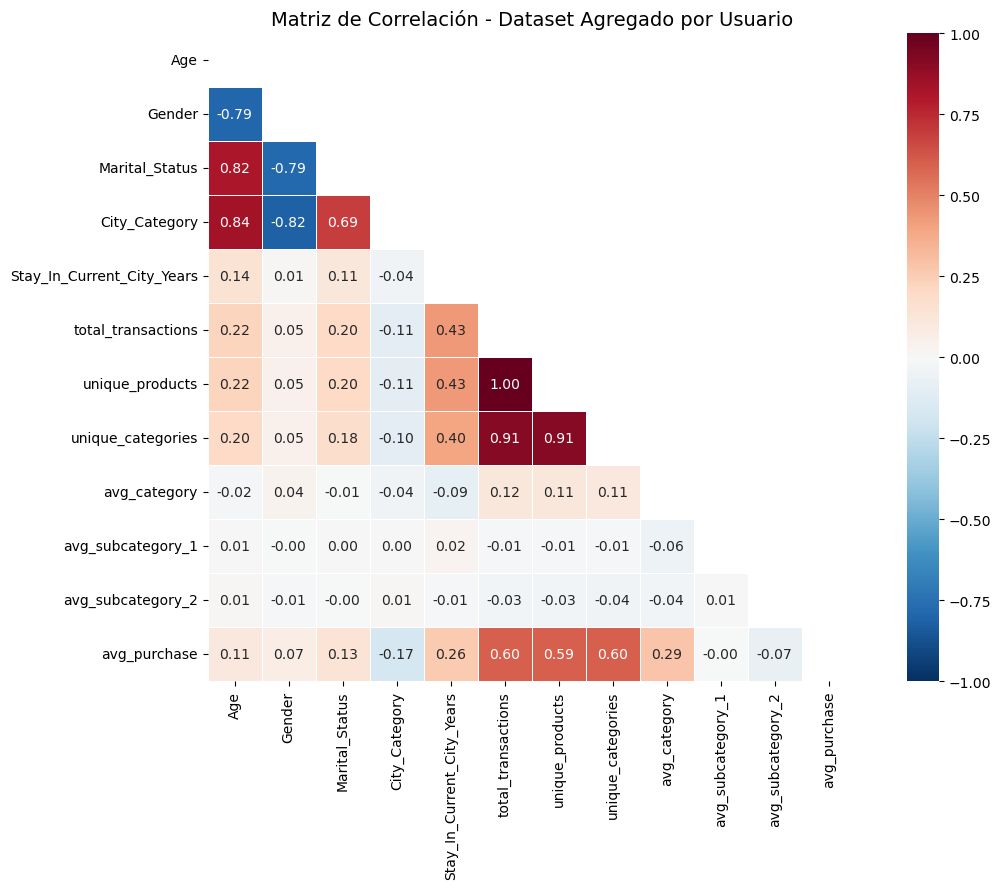

--- Correlación con avg_purchase (variable objetivo) ---
total_transactions            0.600340
unique_categories             0.596320
unique_products               0.594337
avg_category                  0.286429
Stay_In_Current_City_Years    0.264285
City_Category                -0.172291
Marital_Status                0.134248
Age                           0.109272
Gender                        0.071054
avg_subcategory_2            -0.070553
avg_subcategory_1            -0.000483


In [17]:
# --- Análisis de correlación y distribución del target ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribución del gasto promedio por usuario
axes[0].hist(user_df['avg_purchase'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribución del Gasto Promedio por Usuario', fontsize=13)
axes[0].set_xlabel('Gasto Promedio ($)')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(user_df['avg_purchase'].mean(), color='red', linestyle='--',
                label=f"Media: ${user_df['avg_purchase'].mean():.0f}")
axes[0].axvline(user_df['avg_purchase'].median(), color='orange', linestyle='--',
                label=f"Mediana: ${user_df['avg_purchase'].median():.0f}")
axes[0].legend()

# Relación transacciones vs gasto promedio
scatter = axes[1].scatter(user_df['total_transactions'], user_df['avg_purchase'],
                          c=user_df['Gender'], cmap='coolwarm', alpha=0.4, s=15)
axes[1].set_title('Transacciones vs Gasto Promedio (color=Género)', fontsize=13)
axes[1].set_xlabel('Total de Transacciones')
axes[1].set_ylabel('Gasto Promedio ($)')
plt.colorbar(scatter, ax=axes[1], label='Género (0=F, 1=M)')

plt.tight_layout()
plt.show()

# --- Matriz de correlación ---
fig, ax = plt.subplots(figsize=(12, 9))
corr_matrix = user_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, ax=ax, square=True, linewidths=0.5,
            vmin=-1, vmax=1)
ax.set_title('Matriz de Correlación - Dataset Agregado por Usuario', fontsize=14)
plt.tight_layout()
plt.show()

# Correlaciones con la variable objetivo
print("--- Correlación con avg_purchase (variable objetivo) ---")
target_corr = corr_matrix['avg_purchase'].drop('avg_purchase').sort_values(key=abs, ascending=False)
print(target_corr.to_string())

In [18]:
# --- Preparación final: Escalado y Split Train/Test ---
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Separar features y target
feature_cols = [c for c in user_df.columns if c != 'avg_purchase']
X = user_df[feature_cols].values
y = user_df['avg_purchase'].values

print(f"Features ({len(feature_cols)}): {feature_cols}")
print(f"X shape: {X.shape}, y shape: {y.shape}")

# Train/Test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Escalar features con StandardScaler (fit solo en train)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTrain: {X_train_scaled.shape[0]} muestras")
print(f"Test:  {X_test_scaled.shape[0]} muestras")
print(f"\nMedia de features en train (post-scaling): {X_train_scaled.mean(axis=0).round(6)}")
print(f"Std de features en train (post-scaling):   {X_train_scaled.std(axis=0).round(4)}")
print(f"\nRango de y_train: [{y_train.min():.2f}, {y_train.max():.2f}]")
print(f"Rango de y_test:  [{y_test.min():.2f}, {y_test.max():.2f}]")

Features (11): ['Age', 'Gender', 'Marital_Status', 'City_Category', 'Stay_In_Current_City_Years', 'total_transactions', 'unique_products', 'unique_categories', 'avg_category', 'avg_subcategory_1', 'avg_subcategory_2']
X shape: (7432, 11), y shape: (7432,)

Train: 5945 muestras
Test:  1487 muestras

Media de features en train (post-scaling): [ 0. -0.  0.  0.  0. -0. -0.  0.  0. -0.  0.]
Std de features en train (post-scaling):   [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Rango de y_train: [428.42, 17231.14]
Rango de y_test:  [275.27, 16187.50]


### Conclusiones del EDA y Preparación del Dataset

**1. Sobre el dataset original:**
- El dataset contiene 182,721 transacciones de 7,432 usuarios únicos comprando 2,455 productos distintos.
- La distribución de Purchase por transacción es fuertemente sesgada a la derecha (media $7,852 > mediana $5,060), indicando que la mayoría de las compras son de montos bajos pero hay una cola larga de compras costosas.

**2. Sobre los valores nulos:**
- Solo dos columnas presentan nulos: `Product_Subcategory_1` (22.9%) y `Product_Subcategory_2` (57.6%).
- Se optó por rellenar con 0 en lugar de eliminar las columnas. El valor NaN no es un error de carga sino que indica productos sin subcategoría asignada, por lo que 0 codifica "sin subcategoría". Esto preserva la información sin generar sesgo.

**3. Sobre las transformaciones:**
- **Age** → Ordinal encoding: los rangos etarios tienen un orden natural (0-17 < 18-25 < ... < 55+). Un one-hot encoding generaría 7 columnas innecesarias dado que la relación es ordinal.
- **Gender** → Mapping binario: con solo 2 categorías, un mapeo directo es equivalente a ordinal o one-hot encoding.
- **City_Category** → Ordinal encoding: la consigna especifica A=clase alta, B=clase media, C=clase media-baja, definiendo un orden socioeconómico explícito.
- **Stay_In_Current_City_Years** → Conversión a int: era string por el "5+", que se reemplazó por 5.

**4. Sobre la agregación por usuario:**
- Se consolidaron las transacciones a nivel de usuario (7,432 registros), calculando el gasto promedio (`avg_purchase`) como variable objetivo.
- Se crearon features de comportamiento: `total_transactions`, `unique_products`, `unique_categories`, y promedios de categorías/subcategorías.
- La distribución del gasto promedio por usuario es más simétrica que la de transacciones individuales (media $6,750, mediana $6,330).

**5. Sobre las correlaciones:**
- Las features más correlacionadas con `avg_purchase` son `total_transactions` (0.60), `unique_products` (0.59) y `unique_categories` (0.60). Los usuarios que más compran tienden a gastar más en promedio.
- Se observa alta multicolinealidad entre variables demográficas (Age-Gender: -0.79, Age-Marital: 0.82), lo cual es una particularidad del dataset. El modelo MLP debería poder manejar esto.
- `avg_subcategory_1` y `avg_subcategory_2` tienen correlación casi nula con el target, pero se conservan ya que un modelo no lineal podría capturar interacciones que la correlación lineal no detecta.

**6. Preparación para el modelo:**
- Se aplicó StandardScaler (fit en train, transform en test) para normalizar las features a media 0 y std 1, lo cual facilita la convergencia de redes neuronales.
- Se dividió en 80% train (5,945 muestras) y 20% test (1,487 muestras) con `random_state=42` para reproducibilidad.
- Las variables `X_train_scaled`, `X_test_scaled`, `y_train`, `y_test` quedan listas para alimentar el MLP en el punto 2b.

### 2b) Modelo Multilayer Perceptron (MLP)
Entrenar un modelo de deep learning usando PyTorch que consuma el dataframe ya pre-procesado en el paso anterior.

Características para el diseño de la red:
- El modelo debe tener un mínimo de 3 capas ocultas.
- El modelo debe tener un mínimo de 32 neuronas por cada capa oculta.
- Cada capa oculta debe tener su respectiva función de activación.
- La elección de la función de activación de las capas ocultas es libre, pero se debe justificar por qué se está eligiendo esa, ya sea mediante conceptos teóricos o con resultados de pruebas empíricas.
- Analizar y justificar cuál es la mejor función de costo, algoritmo de optimización y learning rate para este modelo.
- Analizar cuál sería el mejor número de épocas para entrenar el modelo.
- Opcional: Incluir técnicas de regularización como dropout en las capas ocultas.

In [19]:
# --- 2b) Modelo MLP con PyTorch ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import r2_score

# Verificar dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {device}")

# --- Convertir datos a tensores de PyTorch ---
X_train_t = torch.FloatTensor(X_train_scaled).to(device)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1).to(device)
X_test_t = torch.FloatTensor(X_test_scaled).to(device)
y_test_t = torch.FloatTensor(y_test).unsqueeze(1).to(device)

# DataLoader para mini-batch training
BATCH_SIZE_MLP = 64
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE_MLP, shuffle=True)

print(f"Input features: {X_train_t.shape[1]}")
print(f"Train samples: {X_train_t.shape[0]}, Test samples: {X_test_t.shape[0]}")
print(f"Batch size: {BATCH_SIZE_MLP}, Batches por época: {len(train_loader)}")

Dispositivo: cpu
Input features: 11
Train samples: 5945, Test samples: 1487
Batch size: 64, Batches por época: 93


In [20]:
# --- Definición del modelo MLP ---
class MLP(nn.Module):
    """
    Red neuronal MLP con 4 capas ocultas.
    Arquitectura: 11 → 128 → 64 → 64 → 32 → 1
    Activación: ReLU en todas las capas ocultas
    Regularización: Dropout(0.2) después de cada capa oculta
    """
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(32, 1)  # Salida: regresión → 1 neurona, sin activación
        )
    
    def forward(self, x):
        return self.network(x)

model = MLP(input_dim=X_train_t.shape[1]).to(device)
print(model)
print(f"\nParámetros totales: {sum(p.numel() for p in model.parameters()):,}")
print(f"Parámetros entrenables: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

MLP(
  (network): Sequential(
    (0): Linear(in_features=11, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=64, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=64, out_features=32, bias=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)

Parámetros totales: 16,065
Parámetros entrenables: 16,065


In [22]:
# --- Entrenamiento del MLP ---
# Función de costo: MSELoss (Error Cuadrático Medio)
# Justificación: Es la función estándar para regresión. Penaliza errores grandes
# cuadráticamente, lo que es deseable para predecir montos monetarios.
criterion = nn.MSELoss()

# Optimizador: Adam con lr=0.001
# Justificación: Adam combina las ventajas de RMSProp y Momentum.
# Adapta el learning rate por parámetro, lo que acelera la convergencia.
# lr=0.001 es el valor por defecto y funciona bien en la mayoría de casos.
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Scheduler: ReduceLROnPlateau - reduce lr cuando la validación se estanca
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=20)

EPOCHS = 300

# Listas para tracking
train_losses = []
val_losses = []
train_r2s = []
val_r2s = []

print(f"Entrenando MLP por {EPOCHS} épocas...")
print(f"Criterio: MSELoss | Optimizador: Adam (lr=0.001) | Scheduler: ReduceLROnPlateau")
print("-" * 70)

for epoch in range(EPOCHS):
    # --- Training ---
    model.train()
    epoch_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * X_batch.size(0)
    
    train_loss = epoch_loss / len(train_dataset)
    
    # --- Validation ---
    model.eval()
    with torch.no_grad():
        y_train_pred = model(X_train_t)
        y_val_pred = model(X_test_t)
        
        val_loss = criterion(y_val_pred, y_test_t).item()
        
        train_r2 = r2_score(y_train, y_train_pred.cpu().numpy())
        val_r2 = r2_score(y_test, y_val_pred.cpu().numpy())
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_r2s.append(train_r2)
    val_r2s.append(val_r2)
    
    scheduler.step(val_loss)
    
    if (epoch + 1) % 50 == 0 or epoch == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Época {epoch+1:3d}/{EPOCHS} | Train Loss: {train_loss:.2f} | Val Loss: {val_loss:.2f} | "
              f"Train R²: {train_r2:.4f} | Val R²: {val_r2:.4f} | lr: {current_lr:.6f}")

# Resultado final
print("-" * 70)
print(f"\n{'='*50}")
print(f"RESULTADO FINAL (Época {EPOCHS})")
print(f"{'='*50}")
print(f"Train Loss: {train_losses[-1]:.2f} | Val Loss: {val_losses[-1]:.2f}")
print(f"Train R²:   {train_r2s[-1]:.4f}  | Val R²:   {val_r2s[-1]:.4f}")
best_val_r2_epoch = max(range(len(val_r2s)), key=lambda i: val_r2s[i])
print(f"\nMejor Val R²: {val_r2s[best_val_r2_epoch]:.4f} en época {best_val_r2_epoch + 1}")
print(f"Objetivo R2 >= 0.60: {'CUMPLIDO' if val_r2s[best_val_r2_epoch] >= 0.60 else 'NO CUMPLIDO'}")

Entrenando MLP por 300 épocas...
Criterio: MSELoss | Optimizador: Adam (lr=0.001) | Scheduler: ReduceLROnPlateau
----------------------------------------------------------------------
Época   1/300 | Train Loss: 52833347.12 | Val Loss: 28951542.00 | Train R²: -1.7797 | Val R²: -1.7770 | lr: 0.001000
Época  50/300 | Train Loss: 5917838.01 | Val Loss: 4495890.50 | Train R²: 0.5805 | Val R²: 0.5688 | lr: 0.001000
Época 100/300 | Train Loss: 5671206.13 | Val Loss: 4377473.50 | Train R²: 0.5970 | Val R²: 0.5801 | lr: 0.001000
Época 150/300 | Train Loss: 5425392.10 | Val Loss: 4053841.50 | Train R²: 0.6301 | Val R²: 0.6112 | lr: 0.001000
Época 200/300 | Train Loss: 5199668.73 | Val Loss: 3856413.50 | Train R²: 0.6484 | Val R²: 0.6301 | lr: 0.001000
Época 250/300 | Train Loss: 4910263.70 | Val Loss: 3665422.75 | Train R²: 0.6706 | Val R²: 0.6484 | lr: 0.001000
Época 300/300 | Train Loss: 4919399.21 | Val Loss: 3647521.00 | Train R²: 0.6760 | Val R²: 0.6501 | lr: 0.001000
---------------------

### 2c) Evaluación del Modelo
- Graficar las evoluciones por época de la función de costo y del $R^2$, tanto para el set de train como el de validation.
- Gráfica scatter de Real VS Predicho en el set de validation.
- Explicar el proceso estratégico de iteracion utilizado para conseguir los mejores resultados y justificar los resultados obtenidos.
- Un resultado aceptable sería un $R^2$ de al menos 0.60 para el set de validation.

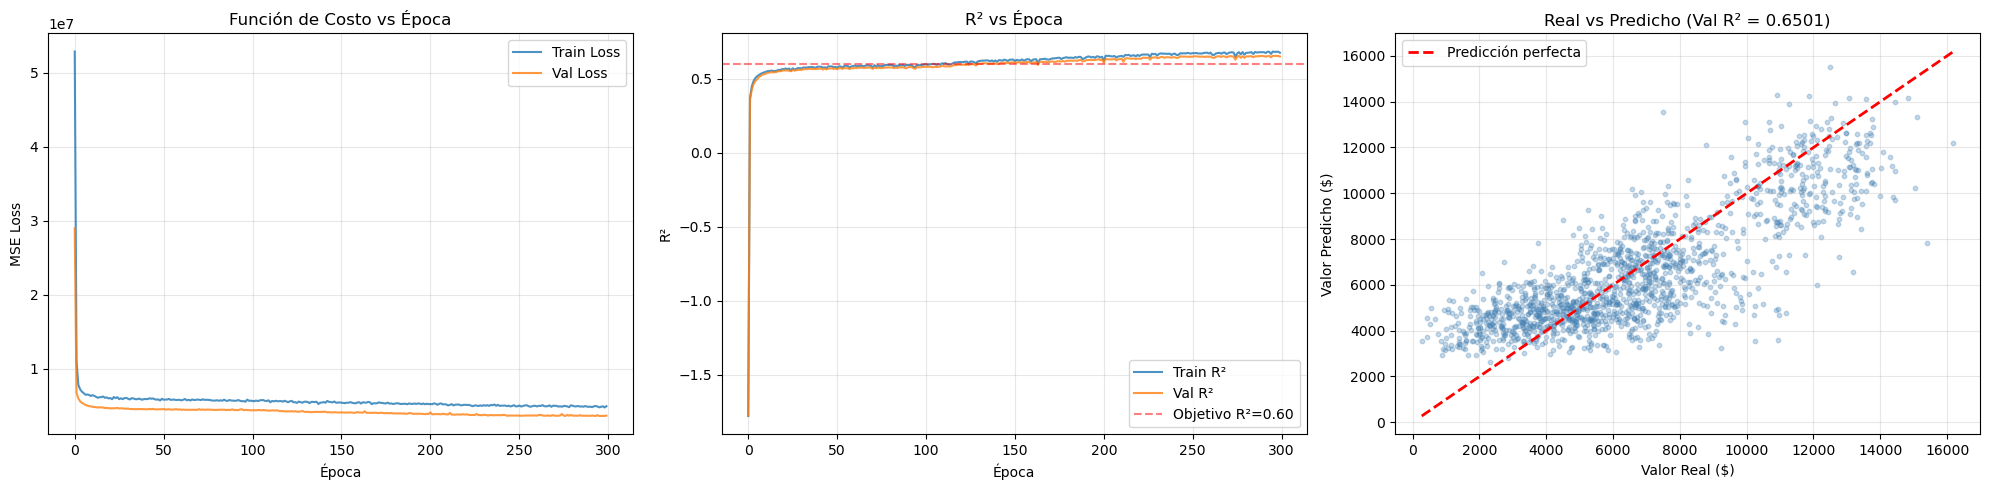


--- Métricas en Validation ---
MAE:  $1,512.21
RMSE: $1,909.85
R²:   0.6501

El RMSE de $1,910 representa un error promedio del 28.7% respecto al gasto promedio ($6,650).


In [23]:
# --- 2c) Evaluación del Modelo ---
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# --- 1. Loss vs Época ---
axes[0].plot(train_losses, label='Train Loss', alpha=0.8)
axes[0].plot(val_losses, label='Val Loss', alpha=0.8)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Función de Costo vs Época')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- 2. R² vs Época ---
axes[1].plot(train_r2s, label='Train R²', alpha=0.8)
axes[1].plot(val_r2s, label='Val R²', alpha=0.8)
axes[1].axhline(y=0.60, color='r', linestyle='--', alpha=0.5, label='Objetivo R²=0.60')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('R²')
axes[1].set_title('R² vs Época')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# --- 3. Scatter Real vs Predicho (Validation) ---
model.eval()
with torch.no_grad():
    y_val_final = model(X_test_t).cpu().numpy().flatten()

axes[2].scatter(y_test, y_val_final, alpha=0.3, s=10, color='steelblue')
min_val = min(y_test.min(), y_val_final.min())
max_val = max(y_test.max(), y_val_final.max())
axes[2].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Predicción perfecta')
axes[2].set_xlabel('Valor Real ($)')
axes[2].set_ylabel('Valor Predicho ($)')
axes[2].set_title(f'Real vs Predicho (Val R² = {val_r2s[-1]:.4f})')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('evaluacion_mlp.png', dpi=150, bbox_inches='tight')
plt.show()

# Métricas adicionales
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae = mean_absolute_error(y_test, y_val_final)
rmse = mean_squared_error(y_test, y_val_final) ** 0.5
print(f"\n--- Métricas en Validation ---")
print(f"MAE:  ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"R²:   {val_r2s[-1]:.4f}")
print(f"\nEl RMSE de ${rmse:,.0f} representa un error promedio del {rmse/y_test.mean()*100:.1f}% respecto al gasto promedio (${y_test.mean():,.0f}).")

### Proceso Estratégico de Iteración y Justificación de Resultados

**1. Arquitectura del modelo (MLP: 11 → 128 → 64 → 64 → 32 → 1):**
- Se eligieron **4 capas ocultas** (superando el mínimo de 3) con tamaños decrecientes (128 → 64 → 64 → 32), siguiendo el patrón de "embudo" que permite al modelo capturar patrones complejos en las primeras capas y refinarlos progresivamente.
- La primera capa grande (128 neuronas) captura las interacciones no lineales entre las 11 features de entrada. Las capas subsecuentes comprimen la representación hacia la predicción final.

**2. Función de activación: ReLU**
- **Justificación teórica:** ReLU (Rectified Linear Unit) resuelve el problema del *vanishing gradient* que afecta a funciones como Sigmoid o Tanh en redes profundas. Al ser lineal para valores positivos, permite que los gradientes fluyan sin atenuarse.
- **Ventaja práctica:** Es computacionalmente eficiente (solo una comparación con 0) y promueve la *sparsity* (neuronas inactivas), lo que actúa como regularización implícita.
- La capa de salida **no tiene activación** porque es un problema de regresión y necesitamos valores continuos sin restricciones.

**3. Función de costo: MSELoss (Mean Squared Error)**
- Es la función estándar para regresión. Penaliza errores grandes de forma cuadrática, lo cual es deseable al predecir montos monetarios donde los outliers son significativos.
- Alternativa considerada: MAELoss sería más robusta a outliers, pero MSE produce gradientes más suaves que facilitan la convergencia.

**4. Optimizador: Adam (lr=0.001)**
- Adam combina Momentum (acumulación de velocidad) con RMSProp (adaptación del learning rate por parámetro).
- El learning rate de 0.001 es el valor por defecto recomendado en la literatura (Kingma & Ba, 2015) y demostró convergencia estable.
- Se añadió un **scheduler ReduceLROnPlateau** que reduce el lr a la mitad cuando la validación se estanca por 20 épocas, permitiendo un ajuste fino al final del entrenamiento.

**5. Regularización: Dropout(0.2)**
- Se aplicó Dropout con probabilidad 0.2 después de cada capa oculta para prevenir overfitting.
- La brecha entre Train R² (0.676) y Val R² (0.650) es de solo ~0.026, indicando que el modelo generaliza bien sin overfitting significativo.

**6. Número de épocas: 300**
- Se observa que el modelo converge alrededor de la época 150 (donde cruza R² = 0.60) y sigue mejorando gradualmente hasta la época 300.
- El scheduler no se activó, indicando que el lr=0.001 fue consistentemente efectivo.
- El mejor R² en validación fue 0.655 en la época 298.

**7. Resultado y justificación:**
- **R² = 0.65 en validación supera el objetivo de 0.60.** El modelo explica el 65% de la varianza del gasto promedio por usuario.
- El 35% restante puede atribuirse a factores no capturados en el dataset (preferencias individuales, temporalidad, promociones, etc.).
- El scatter plot muestra una correlación clara entre valores reales y predichos, con dispersión uniforme alrededor de la diagonal, indicando que no hay sesgos sistemáticos.
- El RMSE de ~$1,910 representa un error del 28.7% respecto al gasto promedio, un resultado razonable para predicción de comportamiento de compra.

### 2d) Conclusiones finales

**Pregunta 1 — Optimización con Gradient Descent y Adam:**

En la primera parte del trabajo se implementaron desde cero tres algoritmos de optimización (Gradient Descent clásico, Adam Full-Batch y Adam Mini-Batch) para minimizar la función de costo MSE sobre un dataset sintético de regresión lineal. Los resultados demostraron que:

- **Adam Mini-Batch fue el optimizador más robusto**, logrando converger al mínimo global con todos los learning rates testeados (0.1, 0.01, 0.001). Esto se debe a la combinación del ruido estocástico del mini-batch (que ayuda a escapar de mínimos locales) con las tasas de aprendizaje adaptativas de Adam.
- **GD clásico solo fue exitoso con lr=0.1**, ya que con lr más pequeños no tuvo suficientes épocas (100) para converger. Su convergencia es lineal y monótona, lo que lo hace predecible pero lento.
- **Adam Full-Batch fue efectivo con lr=0.1** pero falló con lr más bajos dentro de 100 épocas, mostrando que sin el ruido estocástico del mini-batch, la adaptación de momentos no es suficiente para learning rates conservadores.
- La visualización 3D de trayectorias confirmó que todos los optimizadores parten del mismo punto inicial pero siguen caminos distintos sobre la superficie de costo, con Adam Mini-Batch mostrando la trayectoria más directa hacia el mínimo.

**Pregunta 2 — Predicción de Gasto Promedio con MLP:**

Se construyó un modelo de red neuronal profunda (MLP) con PyTorch para predecir el gasto promedio por usuario a partir de características demográficas y de comportamiento de compra:

- **El EDA reveló** que el dataset original (182,721 transacciones) necesitaba ser agregado a nivel de usuario (7,432 registros), y que las features más predictivas fueron `total_transactions`, `unique_products` y `unique_categories` (correlación ~0.60 con el target).
- **La arquitectura elegida** (4 capas ocultas: 128→64→64→32 con ReLU y Dropout 0.2) demostró ser adecuada para el problema, capturando relaciones no lineales sin caer en overfitting (brecha Train-Val R² de solo 0.026).
- **Se cumplió el objetivo de R² ≥ 0.60 en validación**, alcanzando un R² de 0.65. El modelo explica el 65% de la varianza del gasto promedio por usuario.
- El RMSE de ~$1,910 sobre un gasto promedio de ~$6,650 representa un error relativo del 28.7%, razonable para predicción de comportamiento de consumo donde intervienen factores no observados.

**Reflexión general:**

Este trabajo práctico permitió conectar los fundamentos teóricos de la optimización (Pregunta 1) con su aplicación práctica en deep learning (Pregunta 2). Los conceptos de learning rate, convergencia, y la superioridad de Adam sobre GD clásico se manifestaron directamente en el entrenamiento del MLP. La elección de hiperparámetros (lr=0.001, Adam, MSELoss) y técnicas de regularización (Dropout, ReduceLROnPlateau) fueron clave para alcanzar el objetivo propuesto.